# Testing classifiers and models

SECTION 1: SETUP & CONFIGURATION

In [1]:
import socket
print(f"Running on machine: {socket.gethostname()}")

Running on machine: bs-se-t1.us-central1-a.c.sce-innercloud.internal


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Name:", tf.test.gpu_device_name())

2026-02-08 17:19:54.029060: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/sceuser/.virtualenvs/deepfake_final_project/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Num GPUs Available:  1
GPU Name: /device:GPU:0


I0000 00:00:1770571199.170285  319534 gpu_device.cc:2020] Created device /device:GPU:0 with 11331 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [3]:
# ============================================================================
# SECTION 1: GPU FIXES, PATHS & IMPORTS (The Correct Order)
# ============================================================================
import os
import subprocess
import tensorflow as tf  # חייב להיות מיובא ראשון

print("🚀 STARTING MASTER SETUP...")

# ----------------------------------------------------------------------------
# STEP 1: GPU CRITICAL FIXES (Must run before anything else!)
# ----------------------------------------------------------------------------

# א. תיקון זיכרון (מונע קריסת 125MB)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ 1. Memory Growth Enabled (Preventing crash).")
    except RuntimeError as e:
        print(f"⚠️ Memory Error: {e}")
else:
    print("❌ No GPU found! Running on CPU.")

# ב. תיקון קובץ XLA (מונע שגיאות קימפול)
REAL_PATH = "/usr/lib/nvidia-cuda-toolkit/nvvm/libdevice/libdevice.10.bc"
TARGET_LINK = "./libdevice.10.bc"

if os.path.exists(REAL_PATH):
    if not os.path.exists(TARGET_LINK):
        try:
            os.symlink(REAL_PATH, TARGET_LINK)
        except:
            subprocess.run(['ln', '-sf', REAL_PATH, TARGET_LINK])

    # עדכון משתנה הסביבה
    os.environ['XLA_FLAGS'] = "--xla_gpu_cuda_data_dir=./"
    print("✅ 2. Libdevice linked & XLA flags set.")
else:
    print(f"⚠️ Warning: Could not find libdevice at {REAL_PATH}")


# ----------------------------------------------------------------------------
# STEP 2: PATHS & GOOGLE DRIVE CONFIGURATION
# ----------------------------------------------------------------------------
GDRIVE_PATH = os.path.expanduser('~/RealEyes/gdrive')

if os.path.exists(GDRIVE_PATH):
    print(f"✅ 3. Google Drive connected at: {GDRIVE_PATH}")
else:
    print("❌ Error: Google Drive not mounted!")

# הגדרת נתיבים מקוצרים
CODE_PATH = os.path.join(GDRIVE_PATH, 'code')
DATA_PATH = os.path.join(GDRIVE_PATH, 'data_set')
DATA_SPLIT_PATH = os.path.join(GDRIVE_PATH, 'data_set_split')

print(f"📂 Paths Configured:\n   Code: {CODE_PATH}\n   Data: {DATA_PATH}")


# ----------------------------------------------------------------------------
# STEP 3: HEAVY LIBRARY IMPORTS (Only run AFTER GPU fixes!)
# ----------------------------------------------------------------------------
print("📦 4. Importing heavy libraries (Keras, Seaborn, etc)...")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from sklearn.metrics import confusion_matrix, classification_report

# Keras Imports
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC, Precision

print(f"✅ TensorFlow version: {tf.__version__}")

if gpus:
    print(f"✅ READY TO RUN ON GPU: {gpus[0].name}")
else:
    print("🖥️ WARNING: Running on CPU!")

print("=" * 80)

🚀 STARTING MASTER SETUP...
✅ 1. Memory Growth Enabled (Preventing crash).
✅ 2. Libdevice linked & XLA flags set.
✅ 3. Google Drive connected at: /home/sceuser/RealEyes/gdrive
📂 Paths Configured:
   Code: /home/sceuser/RealEyes/gdrive/code
   Data: /home/sceuser/RealEyes/gdrive/data_set
📦 4. Importing heavy libraries (Keras, Seaborn, etc)...
✅ TensorFlow version: 2.20.0
✅ READY TO RUN ON GPU: /physical_device:GPU:0


In [2]:
import os
import subprocess

# create folder to kaggle config
kaggle_dir = os.path.expanduser('~/.config/kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
print(f"✅ Created directory: {kaggle_dir}")

# copping kaggle.json
source = os.path.join(GDRIVE_PATH, 'kaggle.json')
dest = os.path.join(kaggle_dir, 'kaggle.json')

if os.path.exists(source):
    import shutil
    shutil.copy(source, dest)
    print(f"✅ Copied kaggle.json from: {source}")
    print(f"   to: {dest}")

    # Set permissions
    os.chmod(dest, 0o600)
    print(f"✅ Set permissions: 600")
else:
    print(f"❌ kaggle.json not found at: {source}")
    print(f"   Check GDRIVE_PATH: {GDRIVE_PATH}")

# checking
kaggle_path = os.path.expanduser('~/.virtualenvs/deepfake_final_project/bin/kaggle')
if os.path.exists(kaggle_path):
    result = subprocess.run([kaggle_path, 'datasets', 'list', '--max-size', '1000'],
                           capture_output=True, text=True)
    print("\n📊 Kaggle datasets (first 10):")
    print('\n'.join(result.stdout.split('\n')[:10]))
else:
    print(f"❌ Kaggle not found at: {kaggle_path}")

✅ Created directory: /home/sceuser/.config/kaggle
✅ Copied kaggle.json from: /home/sceuser/RealEyes/gdrive/kaggle.json
   to: /home/sceuser/.config/kaggle/kaggle.json
✅ Set permissions: 600

📊 Kaggle datasets (first 10):
ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ishank2005/salary-csv                                           Salary.csv                                                 392  2025-12-29 15:48:58.240000              0         72                1  
mohitsinghrajput1307/practice-dataset1                          Customer Purchase Prediction Dataset                       286  2026-01-02 13:05:59.963000              0         2

In [3]:
import os
import subprocess
from pathlib import Path
import zipfile
import glob

# full path to kaggle
KAGGLE_PATH = os.path.expanduser('~/.virtualenvs/deepfake_final_project/bin/kaggle')

# make folders
Path('./datasets/OpenForensicsV1').mkdir(parents=True, exist_ok=True)
Path('./datasets/cifake').mkdir(parents=True, exist_ok=True)

# download from kaggle
print("📥 Downloading OpenForensics dataset...")
subprocess.run([KAGGLE_PATH, 'datasets', 'download', 'manjilkarki/deepfake-and-real-images',
                '-p', './datasets/OpenForensicsV1'], check=True)

print("📥 Downloading CiFake dataset...")
subprocess.run([KAGGLE_PATH, 'datasets', 'download', 'birdy654/cifake-real-and-ai-generated-synthetic-images',
                '-p', './datasets/cifake'], check=True)

# extract from zip
print("📦 Extracting datasets...")

for zip_file in glob.glob('./datasets/OpenForensicsV1/*.zip'):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('./datasets/OpenForensicsV1/')
    print(f"✅ Extracted: {zip_file}")

for zip_file in glob.glob('./datasets/cifake/*.zip'):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('./datasets/cifake/')
    print(f"✅ Extracted: {zip_file}")

print("✅ All datasets downloaded and extracted!")

📥 Downloading OpenForensics dataset...
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
deepfake-and-real-images.zip: Skipping, found more recently modified local copy (use --force to force download)
📥 Downloading CiFake dataset...
Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
cifake-real-and-ai-generated-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)
📦 Extracting datasets...
✅ Extracted: ./datasets/OpenForensicsV1/deepfake-and-real-images.zip
✅ Extracted: ./datasets/cifake/cifake-real-and-ai-generated-synthetic-images.zip
✅ All datasets downloaded and extracted!


In [5]:
import os
print("📊 GPU MEMORY STATUS:")
# הפקודה הזו מראה את מצב הכרטיס הגרפי בזמן אמת
os.system("nvidia-smi")

📊 GPU MEMORY STATUS:
Thu Jan 22 13:02:56 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.274.02             Driver Version: 535.274.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              11W /  70W |      4MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----

0

In [6]:
# # הרצת קוד אתחול כי יש רשימה של תהליכים שחוסמים אותנו (ניתן לראות ע"י הפונקציה הקודמת של ה-gpu)
# import os
# import signal
# import subprocess
#
# print("🧹 Starting GPU Cleanup...")
#
# # רשימת התהליכים שלקחתי מהתמונה שלך
# # PID 57100 הוא הבעייתי הגדול (11GB)
# zombie_pids = [57100, 23940, 58132, 71799, 92473, 109800]
#
# for pid in zombie_pids:
#     try:
#         print(f"🔫 Killing process {pid}...", end=" ")
#         os.kill(pid, signal.SIGKILL) # הפקודה הזו הורגת את התהליך מיד
#         print("✅ Dead.")
#     except ProcessLookupError:
#         print("already dead (was not found).")
#     except PermissionError:
#         print("❌ Permission denied (not your process).")
#     except Exception as e:
#         print(f"❌ Error: {e}")
#
# print("\n📊 Verifying clean GPU status...")
# subprocess.run("nvidia-smi")

In [4]:
# ============================================================================
# DIAGNOSTIC TOOL: Check GPU, Memory & Paths (FIXED VERSION)
# ============================================================================

import subprocess
import sys
import os
import tensorflow as tf

print("="*80)
print("🔍 GPU & CUDA DIAGNOSTIC REPORT (OPTIMIZED)")
print("="*80)

# 1. APPLY MEMORY FIX (CRITICAL for valid test)
print("\n📍 1. MEMORY CONFIGURATION:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"   ✅ Memory Growth: ENABLED (Preventing 'Out of Memory' crashes)")
    except RuntimeError as e:
        print(f"   ⚠️ Could not set memory growth: {e}")
else:
    print("   ❌ No GPUs found.")

# 2. TEST TENSORFLOW COMPUTATION
print("\n📍 2. TENSORFLOW COMPUTATION TEST:")
try:
    print(f"   ℹ️ TensorFlow version: {tf.__version__}")

    if gpus:
        print("   🧪 Running matrix multiplication on GPU...")
        try:
            with tf.device('/GPU:0'):
                a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
                b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
                c = tf.matmul(a, b)
            print(f"   ✅ SUCCESS! GPU is working correctly.")
            print(f"      Result: {c.numpy().tolist()}")
        except Exception as e:
            print(f"   ❌ FAILED: {e}")
            if "libdevice" in str(e).lower():
                 print("      (Likely due to missing XLA file)")
    else:
         print("   ⚠️ Skipping test (No GPU)")

except Exception as e:
    print(f"   ❌ General Error: {e}")

# 3. VERIFY LIBDEVICE PATH
print("\n📍 3. CHECKING LIBDEVICE PATH:")
# הנתיב שידוע לנו כנכון בשרת שלך
known_path = "/usr/lib/nvidia-cuda-toolkit/nvvm/libdevice/libdevice.10.bc"

if os.path.exists(known_path):
    print(f"   ✅ FOUND libdevice at: {known_path}")
    print("      (This path is valid and ready to be linked)")
else:
    print(f"   ❌ ERROR: Could not find libdevice at: {known_path}")
    print("      Attempting fallback search...")
    # חיפוש גיבוי קצר
    res = subprocess.run(['find', '/usr', '-name', 'libdevice.10.bc'],
                         capture_output=True, text=True)
    if res.stdout:
        print(f"      Found alternative: {res.stdout.strip()}")
    else:
        print("      ❌ Completely missing.")

print("\n" + "="*80)
print("✅ DIAGNOSTIC COMPLETE")
print("="*80)

🔍 GPU & CUDA DIAGNOSTIC REPORT (OPTIMIZED)

📍 1. MEMORY CONFIGURATION:
   ✅ Memory Growth: ENABLED (Preventing 'Out of Memory' crashes)

📍 2. TENSORFLOW COMPUTATION TEST:
   ℹ️ TensorFlow version: 2.20.0
   🧪 Running matrix multiplication on GPU...
   ✅ SUCCESS! GPU is working correctly.
      Result: [[1.0, 3.0], [3.0, 7.0]]

📍 3. CHECKING LIBDEVICE PATH:
   ✅ FOUND libdevice at: /usr/lib/nvidia-cuda-toolkit/nvvm/libdevice/libdevice.10.bc
      (This path is valid and ready to be linked)

✅ DIAGNOSTIC COMPLETE


I0000 00:00:1769096404.905648  117069 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11445 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


# 📊 DATA PREPARATION - section2


In [8]:
#=================== Main pipeline ===================#

#Drive Path
drive_path = GDRIVE_PATH + '/'

DATASET_ROOT = f'{drive_path}data_set_split/'

#Train set
train_datasets = {
    'CiFake': './datasets/cifake/train',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Train',
    'CustomWar': f'{DATASET_ROOT}train'
}

# Validation set
validation_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Validation',
    'CustomWar': f'{DATASET_ROOT}val'
}

# Test set
test_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Test',
    'CustomWar': f'{DATASET_ROOT}test'
}

In [9]:
# ============================================================================
# Split CustomWar Dataset (Run Once)
# ============================================================================

import os
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path

# Check if split already exists
DATASET_ROOT = f'{GDRIVE_PATH}/data_set_split/'

if os.path.exists(DATASET_ROOT):
    print(f"✅ Split dataset already exists at: {DATASET_ROOT}")
    print("   Skipping split process.\n")
else:
    print("📊 Splitting CustomWar dataset into train/val/test (80/10/10)...\n")

    # Source and destination paths
    SOURCE_DIR = Path(GDRIVE_PATH) / 'data_set'
    DEST_DIR = Path(GDRIVE_PATH) / 'data_set_split'

    # Create destination folders
    print("📁 Creating destination folders...")
    for split in ['train', 'val', 'test']:
        for label in ['FAKE', 'REAL']:
            folder = DEST_DIR / split / label
            folder.mkdir(parents=True, exist_ok=True)
            print(f"   Created: {folder}")

    print()

    # Process each label (FAKE and REAL)
    for label in ['FAKE', 'REAL']:
        source_path = SOURCE_DIR / label

        if not source_path.exists():
            print(f"⚠️ Warning: {source_path} does not exist!")
            continue

        # Get all image files
        all_files = [f for f in source_path.iterdir()
                     if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif', '.bmp']]

        print(f"📂 {label}: Found {len(all_files)} images")

        # Split: 80% train, 10% val, 10% test
        train_files, temp_files = train_test_split(all_files, test_size=0.2, random_state=42)
        val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

        print(f"   → Train: {len(train_files)} ({len(train_files)/len(all_files)*100:.1f}%)")
        print(f"   → Val:   {len(val_files)} ({len(val_files)/len(all_files)*100:.1f}%)")
        print(f"   → Test:  {len(test_files)} ({len(test_files)/len(all_files)*100:.1f}%)")

        # Copy files to respective folders
        print(f"   Copying {label} files...")

        errors = 0

        # Train
        for i, file in enumerate(train_files):
            try:
                dest = DEST_DIR / 'train' / label / file.name
                shutil.copy2(str(file), str(dest))
                if (i + 1) % 100 == 0:
                    print(f"      Train: {i+1}/{len(train_files)} copied...")
            except Exception as e:
                print(f"      ❌ Error copying {file.name}: {e}")
                errors += 1

        # Val
        for i, file in enumerate(val_files):
            try:
                dest = DEST_DIR / 'val' / label / file.name
                shutil.copy2(str(file), str(dest))
            except Exception as e:
                print(f"      ❌ Error copying {file.name}: {e}")
                errors += 1

        # Test
        for i, file in enumerate(test_files):
            try:
                dest = DEST_DIR / 'test' / label / file.name
                shutil.copy2(str(file), str(dest))
            except Exception as e:
                print(f"      ❌ Error copying {file.name}: {e}")
                errors += 1

        if errors > 0:
            print(f"   ⚠️ {errors} files failed to copy")
        else:
            print(f"   ✅ All files copied successfully")

        print()

    print("✅ Dataset split completed!")
    print(f"   Location: {DATASET_ROOT}\n")

# Verify the split
print("📊 Final Split Summary:")
print("=" * 60)
for split in ['train', 'val', 'test']:
    split_path = Path(DATASET_ROOT) / split
    if split_path.exists():
        fake_count = len(list((split_path / 'FAKE').iterdir())) if (split_path / 'FAKE').exists() else 0
        real_count = len(list((split_path / 'REAL').iterdir())) if (split_path / 'REAL').exists() else 0
        total = fake_count + real_count
        print(f"{split.upper():5s} - FAKE: {fake_count:4d}, REAL: {real_count:4d}, Total: {total:4d}")
print("=" * 60)

✅ Split dataset already exists at: /home/sceuser/RealEyes/gdrive/data_set_split/
   Skipping split process.

📊 Final Split Summary:
TRAIN - FAKE: 1322, REAL:  619, Total: 1941
VAL   - FAKE:  165, REAL:   77, Total:  242
TEST  - FAKE:  166, REAL:   78, Total:  244


In [10]:
# ============================================================================
# Helper Function: Load Dataset Images (FIXED LABELS)
# ============================================================================
import os
import numpy as np
import mimetypes

def load_dataset_images(dataset_path, max_images=None):
    """Load image paths and labels from a dataset directory with STRICT label assignment."""
    image_paths = []
    labels = []

    # ONLY these extensions are valid
    valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}

    folders = os.listdir(dataset_path)

    # מיון כדי שהסדר יהיה צפוי (למרות שאנחנו מתקנים את זה למטה)
    folders.sort()

    skipped_count = 0

    for folder in folders:
        path = os.path.join(dataset_path, folder)
        if not os.path.isdir(path):
            continue

        # =========================================================
        # התיקון הקריטי: קביעת תווית לפי שם התיקייה במפורש!
        # =========================================================
        folder_upper = folder.upper()

        if folder_upper == 'FAKE':
            current_label = 1  # תמיד 1 לזיוף
        elif folder_upper == 'REAL':
            current_label = 0  # תמיד 0 לאמיתי
        else:
            print(f"⚠️ Warning: Unknown folder name '{folder}'. Skipping.")
            continue
        # =========================================================

        for i, filename in enumerate(os.listdir(path)):
            if max_images and i >= max_images:
                break

            file_path = os.path.join(path, filename)

            # Check if it's a file
            if not os.path.isfile(file_path):
                continue

            # Check file extension
            ext = os.path.splitext(filename)[1].lower()
            if ext not in valid_extensions:
                skipped_count += 1
                continue

            # MIME type check
            mime_type, _ = mimetypes.guess_type(file_path)
            if mime_type and mime_type not in {'image/jpeg', 'image/png', 'image/gif', 'image/bmp'}:
                skipped_count += 1
                continue

            image_paths.append(file_path) # list of all the pictures - where does each pic locate
            labels.append(current_label) # list of numbres 0, 1 that match to pictures (real/fake)

    if skipped_count > 0:
        print(f"   ⚠️ Skipped {skipped_count} non-standard files in {dataset_path}")

    print(f"   ✅ Loaded {len(image_paths)} valid images from {dataset_path}")
    return image_paths, np.array(labels)

נחנו צריכים לבדוק את הטעינה של הדאטה מזה מעלה  והאם הוא באמת מדלג על תמונות שהן לא בפורמט # א

In [11]:
# ============================================================================
# AUTOMATIC SMART LOADING (The "Golden Ratio" 1:3 Strategy)
# ============================================================================
import os
import numpy as np

# פונקציית עזר לספירת תמונות בתיקיית העוגן
def count_images_in_dataset(dataset_path):
    """Counts total images inside a dataset path to serve as anchor."""
    total = 0
    if not os.path.exists(dataset_path):
        return 0
    for subfolder in os.listdir(dataset_path):
        sub_path = os.path.join(dataset_path, subfolder)
        if os.path.isdir(sub_path):
            total += len([f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return total

# הפונקציה הראשית שטוענת בצורה דינמית
def load_balanced_datasets(datasets_dict, purpose_name):
    """
    Loads datasets dynamically.
    Rule: Take ALL War images. For others, take (War_Count * 3).
    """
    print(f"\n⚖️  Processing {purpose_name} Sets (Smart-Balancing)...")
    print("="*50)

    # 1. מציאת ה"עוגן" - כמה תמונות יש במאגר המלחמה?
    # אנחנו מניחים שהמפתח במילון הוא 'CustomWar' בדיוק כמו שהגדרת בתא הקודם
    war_path = datasets_dict.get('CustomWar')

    if not war_path:
        print("⚠️ CustomWar path not found in dictionary! Defaulting to 5000.")
        war_count = 0
    else:
        war_count = count_images_in_dataset(war_path)

    # 2. חישוב המגבלה למאגרים האחרים
    if war_count == 0: #fallback
        dynamic_limit = 5000
    else:
        # השינוי כאן: מכפילים ב-3 כדי לקבל דאטה גדול יותר
        # אם זה סט ולידציה או טסט, אפשר להקטין את המכפיל כדי לא להעמיס סתם
        if purpose_name == "TRAIN":
            multiplier = 3.0
        else:
            multiplier = 1.0 # בוולידציה נשמור על יחס שווה יותר (1:1) לבדיקה הוגנת

        dynamic_limit = int(war_count * multiplier)

        print(f"   ⚔️  CustomWar Count: {war_count} images (Anchor)")
        print(f"   🌎  External Datasets Limit: {dynamic_limit} images (Factor x{multiplier})")

    all_paths = []
    all_labels = []

    # 3. לולאת הטעינה
    for ds_name, ds_path in datasets_dict.items():
        # עבור המלחמה - תמיד לוקחים הכל!
        if ds_name == 'CustomWar':
            current_limit = None
            print(f"   📥 Loading {ds_name} (ALL)...")

        # עבור האחרים - משתמשים בגבול המוגדל
        else:
            current_limit = dynamic_limit
            print(f"   📥 Loading {ds_name} (Limit: {current_limit})...")

        # כאן אנחנו קוראים לפונקציה הקודמת שלך (load_dataset_images)
        # תוודאי שהתא הקודם שמגדיר אותה הורץ כבר!
        paths, labels = load_dataset_images(ds_path, max_images=current_limit)
        all_paths.extend(paths)
        all_labels.extend(labels)

    return all_paths, all_labels

# ============================================================================
# EXECUTE LOADING
# ============================================================================

# Train
print("🏗️ Building Training Set...")
train_image_paths, train_labels = load_balanced_datasets(train_datasets, "TRAIN")

# Validation
print("\n🏗️ Building Validation Set...")
validation_image_paths, val_labels = load_balanced_datasets(validation_datasets, "VALIDATION")

# Test
print("\n🏗️ Building Test Set...")
test_image_paths, test_labels = load_balanced_datasets(test_datasets, "TEST")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
train_labels = np.array(train_labels)

print("\n" + "="*50)
print("📊 FINAL TRAIN SET SUMMARY:")
print(f"   Total Images: {len(train_labels)}")
print(f"   Real Images (0): {np.sum(train_labels == 0)}")
print(f"   Fake Images (1): {np.sum(train_labels == 1)}")
print("="*50)

📥 Loading datasets...

Loading CiFake training data...
   ✅ Loaded 10000 valid images from ./datasets/cifake/train
Loading OpenForensics training data...
   ✅ Loaded 10000 valid images from ./datasets/OpenForensicsV1/Dataset/Train
Loading CustomWar training data...
   ✅ Loaded 1941 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/train
Loading CiFake validation data...
   ✅ Loaded 4000 valid images from ./datasets/cifake/test
Loading OpenForensics validation data...
   ✅ Loaded 4000 valid images from ./datasets/OpenForensicsV1/Dataset/Validation
Loading CustomWar validation data...
   ✅ Loaded 242 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/val
Loading CiFake test data...
   ✅ Loaded 20000 valid images from ./datasets/cifake/test
Loading OpenForensics test data...
   ✅ Loaded 10905 valid images from ./datasets/OpenForensicsV1/Dataset/Test
Loading CustomWar test data...
   ✅ Loaded 244 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/test



In [12]:
# ============================================================================
# Dataset Statistics (Dynamic & Corrected)
# ============================================================================

import numpy as np

print("\n📊 Dataset Statistics (AUTO-CALCULATED):")
print("=" * 60)
print(f"Training set:   {len(train_image_paths):,} images")
print(f"Validation set: {len(validation_image_paths):,} images")
print(f"Test set:       {len(test_image_paths):,} images")
print("-" * 60)
print(f"Total:          {len(train_image_paths) + len(validation_image_paths) + len(test_image_paths):,} images")
print("=" * 60)

# Convert to numpy arrays for easier counting
train_labels = np.array(train_labels)
val_labels = np.array(val_labels)
test_labels = np.array(test_labels)

# Label distribution
# Note: Based on our loading function -> Real=0, Fake=1
print("\n📈 Label Distribution:")
print("-" * 60)
print(f"Training set:")
print(f"  - Label 0 (Real): {np.sum(train_labels == 0):,}")
print(f"  - Label 1 (Fake): {np.sum(train_labels == 1):,}")
print(f"\nValidation set:")
print(f"  - Label 0 (Real): {np.sum(val_labels == 0):,}")
print(f"  - Label 1 (Fake): {np.sum(val_labels == 1):,}")
print(f"\nTest set:")
print(f"  - Label 0 (Real): {np.sum(test_labels == 0):,}")
print(f"  - Label 1 (Fake): {np.sum(test_labels == 1):,}")
print("-" * 60)

# בדיקת איזון מהירה
fake_ratio = np.sum(train_labels == 1) / len(train_labels)
print(f"\n⚖️ Balance Check (Train): {fake_ratio:.1%} Fake images")
if 0.4 <= fake_ratio <= 0.6:
    print("✅ Dataset is well balanced!")
else:
    print("⚠️ Dataset might be imbalanced, check weights.")
print("=" * 60)


📊 Dataset Statistics:
Training set:   21,941 images
Validation set: 8,242 images
Test set:       31,149 images
Total:          61,332 images

📈 Label Distribution:
------------------------------------------------------------
Training set:
  - Label 0 (Fake): 10,619
  - Label 1 (Real): 11,322

Validation set:
  - Label 0 (Fake): 4,077
  - Label 1 (Real): 4,165

Test set:
  - Label 0 (Fake): 15,491
  - Label 1 (Real): 15,658
------------------------------------------------------------

📂 Dataset Breakdown:
------------------------------------------------------------
Training set:
  - CiFake: 5,000 (limited)
  - OpenForensics: 5,000 (limited)
  - CustomWar: 1,941 (all)

Validation set:
  - CiFake: 2,000 (limited)
  - OpenForensics: 2,000 (limited)
  - CustomWar: 242 (all)

Test set:
  - CiFake: 20,000 (all)
  - OpenForensics: 10,905 (all)
  - CustomWar: 244 (all)
------------------------------------------------------------


#  SECTION 3: SRM Filters & Autoencoder

In [ ]:
# ============================================================================
# IMPROVED SRM Filters (8 Filters + Tanh Activation)
# ============================================================================

import numpy as np
import tensorflow as tf

# 1. הגדרת הפילטרים הקיימים (5x5)
# -------------------------------
filters_5x5 = [
    # Filter 1: Laplacian-High Boost
    [[0, 0, -1, 0, 0],
     [0, -1, 2, -1, 0],
     [-1, 2, 4, 2, -1],
     [0, -1, 2, -1, 0],
     [0, 0, -1, 0, 0]],

    # Filter 2: Edge & Noise Enhancer
    [[-1, 2, -2, 2, -1],
     [2, -6, 8, -6, 2],
     [-2, 8, -12, 8, -2],
     [2, -6, 8, -6, 2],
     [-1, 2, -2, 2, -1]],

    # Filter 3: Diagonal Residuals
    [[2, -1, 0, -1, 2],
     [-1, -2, 3, -2, -1],
     [0, 3, 0, 3, 0],
     [-1, -2, 3, -2, -1],
     [2, -1, 0, -1, 2]],

    # Filter 4: Vertical Edge
    [[0, 0, 0, 0, 0],
     [1, -2, 1, -2, 1],
     [0, 0, 0, 0, 0],
     [-1, 2, -1, 2, -1],
     [0, 0, 0, 0, 0]],
    # Filter 5: Spam/High-Freq
    [[1, -4, 6, -4, 1],
     [-4, 16, -24, 16, -4],
     [6, -24, 36, -24, 6],
     [-4, 16, -24, 16, -4],
     [1, -4, 6, -4, 1]],
]

# 2. תוספת: פילטרים קטנים (3x3) מרופדים ל-5x5
# ---------------------------------------------
# פילטרים אלו (Min-Max) טובים מאוד לזיהוי גבולות דקים של זיוף
filters_3x3_raw = [
    [[0, -1, 0],
     [-1, 4, -1],
     [0, -1, 0]],  # Basic Laplacian

    [[-1, 2, -1],
     [2, -4, 2],
     [-1, 2, -1]], # Residual

    [[-1, -1, -1],
     [-1, 8, -1],
     [-1, -1, -1]] # Point detection
]

# פונקציית עזר להרחבת הפילטרים מ-3x3 ל-5x5 (עם אפסים מסביב)
def pad_3x3_to_5x5(kernels_3x3):
    padded_kernels = []
    for k in kernels_3x3:
        # יוצר מסגרת של אפסים מסביב ל-3x3 כדי שיהפוך ל-5x5
        padded = np.pad(k, ((1, 1), (1, 1)), mode='constant', constant_values=0)
        padded_kernels.append(padded)
    return padded_kernels

filters_3x3_padded = pad_3x3_to_5x5(filters_3x3_raw)

# איחוד כל הפילטרים (סה"כ 8)
all_filters = np.array(filters_5x5 + filters_3x3_padded, dtype=np.float32)

print(f"✅ IMPROVED SRM Defined: {len(all_filters)} filters of size 5x5")


# 3. מחלקת השכבה המשופרת (כוללת Tanh)
# ------------------------------------
class SRMLayer(tf.keras.layers.Layer):
    """
    Enhanced SRM Layer with Tanh activation for better noise isolation.
    """
    def __init__(self, **kwargs):
        super(SRMLayer, self).__init__(**kwargs)
        # Convert to TF format: (height, width, in_channels, out_channels)
        # In channels = 1 (we apply to each RGB channel separately)
        # Out channels = 8 (number of filters)
        srm_filters_transposed = np.transpose(all_filters, (2, 3, 1, 0)) # (5, 5, 1, 8)
        self.srm_kernels = tf.constant(srm_filters_transposed, dtype=tf.float32)

    def call(self, inputs):
        """
        Input: (batch, 256, 256, 3)
        Output: (batch, 256, 256, 24) -> 8 filters * 3 channels
        """
        channels = tf.split(inputs, num_or_size_splits=3, axis=-1)
        feature_maps = []

        for channel in channels:
            # 1. Convolution
            fm = tf.nn.conv2d(channel, self.srm_kernels, strides=1, padding='SAME')

            # 2. Tanh Activation (השיפור הקריטי!)
            # זה מונע ערכים קיצוניים ועוזר למודל להתמקד במרקם (Texture)
            fm = tf.tanh(fm)

            feature_maps.append(fm)

        return tf.concat(feature_maps, axis=-1)

print("✅ Enhanced SRMLayer class defined (with Tanh activation)")

In [14]:
# ============================================================================
# SRM Filters Application Function (UPDATED: 8 Filters + Tanh)
# ============================================================================

# 1. המרה של הפילטרים החדשים (all_filters) לפורמט של TensorFlow
# שימי לב: אנחנו משתמשים ב-all_filters שהגדרנו בתא הקודם!
srm_filters_tf = tf.constant(np.transpose(all_filters, (2, 3, 1, 0)), dtype=tf.float32)

def apply_srm_filters_tf(image):
    """
    Apply IMPROVED SRM filters (8 filters + Tanh) to an RGB image.

    Args:
        image: Tensor of shape (batch, height, width, 3) or (height, width, 3)

    Returns:
        Feature maps of shape (batch, 256, 256, 24) -> (8 filters * 3 channels)
    """
    # Ensure batch dimension
    if len(image.shape) == 3:
        image = image[tf.newaxis, ...]
        squeeze = True
    else:
        squeeze = False

    # Resize to 256x256 (standard size)
    # הערה: אנחנו משאירים את זה 256 כי זה הגודל הנוח ל-SRM ול-Autoencoder
    image = tf.image.resize(image, [256, 256])

    # Split into R, G, B channels
    channels = tf.split(image, num_or_size_splits=3, axis=-1)

    # Apply all 8 filters to each channel
    feature_maps = []
    for channel in channels:
        # 1. Convolution (Apply filters)
        fm = tf.nn.conv2d(channel, srm_filters_tf, strides=1, padding='SAME')

        # 2. Activation (Normalize noise) - השיפור הקריטי
        fm = tf.tanh(fm)

        feature_maps.append(fm)

    # Concatenate feature maps: Output depth will be 24 instead of 15
    result = tf.concat(feature_maps, axis=-1)

    # Remove batch dimension if input was single image
    if squeeze:
        result = result[0]

    return result

print("✅ apply_srm_filters_tf() function updated")
print("   Input: RGB image (H, W, 3)")
print("   Output: SRM feature maps (256, 256, 24)") # שימי לב שהמספר השתנה ל-24

✅ apply_srm_filters_tf() function defined
   Input: RGB image (H, W, 3)
   Output: SRM feature maps (256, 256, 15)


In [15]:
# ============================================================================
# TRAIN NEW AUTOENCODER (Retraining for 24 Channels)
# ============================================================================
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# 1. הגדרת הנתיב המדויק לשמירה
# -----------------------------
# הנתיב הבסיסי של הפרויקט שלך
BASE_PROJECT_PATH = '/home/sceuser/RealEyes/gdrive/deepfake_image_project/code'

# יצירת הנתיב המלא: models -> our_models -> new_ae
AE_SAVE_DIR = os.path.join(BASE_PROJECT_PATH, 'models', 'our_models', 'new_ae')

# יצירת התיקייה אם היא לא קיימת
if not os.path.exists(AE_SAVE_DIR):
    os.makedirs(AE_SAVE_DIR)
    print(f"✅ Created new directory: {AE_SAVE_DIR}")

# שמות הקבצים לשמירה
# קובץ 1: המודל הכי טוב (לפי ה-Callback)
checkpoint_filename = 'best_srm_autoencoder_24ch.keras'
ae_checkpoint_path = os.path.join(AE_SAVE_DIR, checkpoint_filename)

# קובץ 2: המודל הסופי (אחרי שהאימון נגמר)
final_filename = 'final_srm_autoencoder_24ch.keras'
ae_final_path = os.path.join(AE_SAVE_DIR, final_filename)

print(f"📂 Checkpoint path: {ae_checkpoint_path}")


# 2. הכנת הנתונים לאימון האוטואנקודר
# ----------------------------------
# פונקציה שממפה את התמונה ל-SRM Features (גם קלט וגם פלט)
def prepare_for_ae(image, label):
    srm_features = apply_srm_filters_tf(image)
    return srm_features, srm_features  # Input = Target

print("⚙️ Preparing data for Autoencoder (mapping images to SRM features)...")
# שימוש ב-tf.data למיפוי מהיר
# (אנחנו מניחים ש-train_ds ו-val_ds כבר קיימים מהשלבים הקודמים)
ae_train_ds = train_ds.map(prepare_for_ae, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
ae_val_ds = val_ds.map(prepare_for_ae, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)


# 3. הגדרת Callbacks
# ------------------
ae_callbacks = [
    # שומר את המודל *תוך כדי ריצה* בכל פעם שיש שיפור
    ModelCheckpoint(
        filepath=ae_checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    # עוצר אם אין שיפור
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # מוריד את קצב הלמידה כשנתקעים
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# 4. הרצת האימון (Training)
# -------------------------
print("🚀 Starting Autoencoder Training (New Architecture)...")

history_ae = autoencoder.fit(
    ae_train_ds,
    validation_data=ae_val_ds,
    epochs=20,
    callbacks=ae_callbacks,
    verbose=1
)

# 5. שמירה מפורשת בסוף האימון (לבקשתך)
# ------------------------------------
print("\n💾 Saving Final Model...")
autoencoder.save(ae_final_path)
print(f"✅ Final model explicitly saved to: {ae_final_path}")

# עדכון: אם ה-Checkpoint שמר מודל טוב יותר, נדאג שנדע מזה
print(f"✅ Best checkpoint saved to: {ae_checkpoint_path}")
print("🎉 Autoencoder training and saving complete!")


2026-01-22 13:03:51.929243: W external/local_xla/xla/service/gpu/llvm_gpu_backend/default/nvptx_libdevice_path.cc:41] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykernel_launcher.runfiles/cuda_nvdisasm
  ipykernel_launcher.runfiles/nvidia_nvshmem
  ipykern/cuda_nvcc
  ipykern/cuda_nvdisasm
  ipykern/nvidia_nvshmem
  
  /usr/local/cuda
  /opt/cuda
  /home/sceuser/.virtualenvs/model_project/lib/python3.12/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/model_project/lib/python3.12/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/model_project/lib/python3.12/site-packages/tensorflow/python/platform/../../cuda
  /home/sceuser/.virtualenvs/model_project/lib/python3.12/site-pa

✅ Autoencoder architecture built

📊 Autoencoder Summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ srm_input (InputLayer)          │ (None, 256, 256, 15)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 256, 256, 15)   │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 128, 128, 15)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 128, 128, 32)   │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling2D)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv4 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool4 (MaxPooling2D)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv5 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (MaxPooling2D)   │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up3 (UpSampling2D)          │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv4 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up4 (UpSampling2D)          │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv5 (Conv2D)              │ (None, 128, 128, 15)   │         4,335 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up5 (UpSampling2D)          │ (None, 256, 256, 15)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 256, 256, 15)   │         2,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377,663 (5.26 MB)

...

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ srm_input (InputLayer)          │ (None, 256, 256, 15)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 256, 256, 15)   │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 128, 128, 15)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 128, 128, 32)   │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling2D)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv4 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool4 (MaxPooling2D)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv5 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (MaxPooling2D)   │ (None, 8, 8, 256)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,912 (1.50 MB)

 Trainable params: 393,912 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ============================================================================
# LOAD TRAINED AUTOENCODER (For Future Runs)
# ============================================================================
from tensorflow.keras.models import load_model, Model
import os

# 1. הגדרת הנתיב למודל החדש שלך
# -----------------------------
BASE_PROJECT_PATH = '/home/sceuser/RealEyes/gdrive/deepfake_image_project/code'
AE_SAVE_DIR = os.path.join(BASE_PROJECT_PATH, 'models', 'our_models', 'new_ae')
ae_final_path = os.path.join(AE_SAVE_DIR, 'final_srm_autoencoder_24ch.keras')

# 2. פונקציית טעינה וחילוץ ה-Encoder
# ----------------------------------
def load_and_extract_encoder(model_path):
    print(f"📥 Attempting to load Autoencoder from: {model_path}")

    if not os.path.exists(model_path):
        print("❌ Error: Model file not found! Please run the training cell above first.")
        return None, None

    try:
        # א. טעינת המודל השלם
        loaded_ae = load_model(model_path)
        print("   ✅ Full Autoencoder loaded.")

        # ב. חילוץ ה-Encoder מתוך המודל
        # אנחנו מבקשים מ-Keras לבנות מודל חדש:
        # הקלט: אותו קלט של האוטואנקודר
        # הפלט: השכבה שקראנו לה 'encoder_output' (בפונקציית הבנייה)
        encoder_part = Model(inputs=loaded_ae.input, outputs=loaded_ae.get_layer('encoder_output').output)
        print("   ✅ Encoder extracted successfully (Input -> Latent Space).")

        return loaded_ae, encoder_part

    except Exception as e:
        print(f"❌ Critical Error loading model: {e}")
        return None, None

# 3. ביצוע הטעינה
# ---------------
# בדיקה: אם המשתנה 'autoencoder' כבר קיים בזיכרון (כי אימנו הרגע), לא חייבים לטעון,
# אבל ליתר ביטחון נריץ את זה כדי לוודא שהקובץ תקין ושאנחנו מסונכרנים.
if os.path.exists(ae_final_path):
    autoencoder, encoder = load_and_extract_encoder(ae_final_path)

    # בדיקת תקינות
    print("\n📊 Loaded Encoder Summary:")
    encoder.summary()
else:
    print("⚠️ Model file not found. Make sure you ran the Training Cell above!")

⏭️ Skipping training - using pre-trained autoencoder


In [17]:
# ============================================================================
# Clear GPU Memory
# ============================================================================

import gc
import tensorflow as tf

print("🧹 Clearing GPU memory...")

# Clear TensorFlow session
tf.keras.backend.clear_session()

# Force garbage collection
gc.collect()

# Check GPU memory
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Reset memory growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory cleared and memory growth enabled")
    except RuntimeError as e:
        print(f"⚠️ {e}")
else:
    print("🖥️ Running on CPU")

print("=" * 60)

🧹 Clearing GPU memory...
⚠️ Physical devices cannot be modified after being initialized


In [18]:
# ============================================================================
# SECTION 3 Complete - Ready for Model Training- לשנות את התא הזה- לעשות סיכום עדכני
# ============================================================================

print("✅ Encoder loaded and ready for use")
print("   (Skipping test to save GPU memory for training)")

print("\n" + "="*60)
print("✅ SECTION 3 COMPLETE!")
print("="*60)
print("\n📋 Summary:")
print("   ✓ SRM filters defined (5 filters)")
print("   ✓ SRMLayer class created")
print("   ✓ apply_srm_filters_tf() function ready")
print("   ✓ Autoencoder architecture built")
print("   ✓ Pre-trained autoencoder loaded")
print("   ✓ Encoder ready for feature extraction")
print("\n🎯 Next: Section 4 - CNN-SRM Model")

✅ Encoder loaded and ready for use
   (Skipping test to save GPU memory for training)

✅ SECTION 3 COMPLETE!

📋 Summary:
   ✓ SRM filters defined (5 filters)
   ✓ SRMLayer class created
   ✓ apply_srm_filters_tf() function ready
   ✓ Autoencoder architecture built
   ✓ Pre-trained autoencoder loaded
   ✓ Encoder ready for feature extraction

🎯 Next: Section 4 - CNN-SRM Model


# SECTION 4: 🎯 MODEL 1 - CNN-SRM

In [19]:
# ============================================================================
# CNN-SRM Preprocessing - Create SRM Dataset (FIXED)
# ============================================================================

def create_srm_dataset(image_paths, labels, batch_size=32):
    """
    Create a TensorFlow dataset that ONLY applies SRM filters.
    The Encoder is embedded INSIDE the model, so we don't apply it here.

    Args:
        image_paths: List of image file paths
        labels: Corresponding labels
        batch_size: Batch size

    Returns:
        tf.data.Dataset with shape (256, 256, 15)
    """

    def process_image(path, label):
        """Process single image through SRM filters only."""
        # Load image
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.cast(img, tf.float32) / 255.0

        # Apply SRM filters ONLY
        srm_features = apply_srm_filters_tf(img)  # (256, 256, 15)

        return srm_features, label

    # Create dataset from paths
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    # Map processing function
    dataset = dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Batch the data
    dataset = dataset.batch(batch_size)

    # Prefetch for performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

print("✅ FIXED create_srm_dataset() function defined")
print("   Input: image paths + labels")
print("   Output: (256, 256, 15) -> Matches model input!")

✅ FIXED create_srm_dataset() function defined
   Input: image paths + labels
   Output: (256, 256, 15) -> Matches model input!


In [20]:
# ============================================================================
# Prepare Datasets for CNN-SRM (Reloading with correct shape)
# ============================================================================

print("📦 Creating SRM datasets (Correct Shape)...")
print("=" * 60)

# Create training dataset
print("\n🔄 Processing training data...")
train_srm_dataset = create_srm_dataset(
    train_image_paths,
    train_labels,
    batch_size=32
)

# Create validation dataset
print("\n🔄 Processing validation data...")
val_srm_dataset = create_srm_dataset(
    validation_image_paths,
    val_labels,
    batch_size=32
)

# Create test dataset
print("\n🔄 Processing test data...")
test_srm_dataset = create_srm_dataset(
    test_image_paths,
    test_labels,
    batch_size=32
)

print(f"✅ Test dataset ready: {len(test_image_paths)} images")
print("\n" + "="*60)
print("✅ All datasets ready for evaluation!")
print("="*60)

📦 Creating SRM datasets (Correct Shape)...

🔄 Processing training data...

🔄 Processing validation data...

🔄 Processing test data...
✅ Test dataset ready: 31149 images

✅ All datasets ready for evaluation!


In [21]:
# ============================================================================
# Load Pre-trained CNN-SRM Model
# ============================================================================

import os

# Find available CNN-SRM models
print("🔍 Looking for pre-trained CNN-SRM models...")
print("=" * 60)

# Check for models in different directories
model_paths = [
    os.path.join(CODE_PATH, 'models/NA-VGG/128_SRM_CNN_22_7_25_NEW_openforensics.keras'),
    os.path.join(CODE_PATH, 'models/OpenForensics/256_SRM_CNN_NEW_openforensics.keras'),
    os.path.join(CODE_PATH, 'models/all2/256_SRM_CNN_NEW.keras'),
]

# Try to load the first available model
cnn_srm = None
loaded_model_path = None

for model_path in model_paths:
    if os.path.exists(model_path):
        print(f"\n📂 Found model at:")
        print(f"   {model_path}")
        try:
            cnn_srm = tf.keras.models.load_model(model_path, compile=False)
            loaded_model_path = model_path
            print("✅ Model loaded successfully!")
            break
        except Exception as e:
            print(f"❌ Failed to load: {e}")
            continue

if cnn_srm is None:
    print("\n❌ No pre-trained CNN-SRM model found!")
    print("\n💡 Available models in your directory:")

    # List all available models
    import glob
    all_models = glob.glob(f"{CODE_PATH}/models/**/*SRM*.keras", recursive=True)
    for m in all_models:
        print(f"   - {m}")

    print("\n⚠️ Please update model_paths list with the correct path")
    print("   OR train a new model (see commented code at end of this cell)")
else:
    # Recompile the model
    cnn_srm.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    print(f"\n📊 Model Summary:")
    cnn_srm.summary()

    print(f"\n💾 Loaded from: {loaded_model_path}")

print("\n" + "="*60)

# ============================================================================
# OPTIONAL: Train a NEW model instead
# ============================================================================
"""
If you want to train a NEW CNN-SRM model with different parameters,
uncomment the code below:

from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, LeakyReLU,
    Dropout, GlobalAveragePooling2D, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

def build_srm_cnn(input_shape=(8, 8, 256)):
    input_layer = Input(shape=input_shape, name='srm_latent_input')

    # Block 1
    x = Conv2D(64, (3, 3), padding='same', name='block1_conv')(input_layer)
    x = BatchNormalization(name='block1_bn')(x)
    x = LeakyReLU(alpha=0.1, name='block1_lrelu')(x)
    x = Dropout(0.3, name='block1_drop')(x)

    # Block 2
    x = Conv2D(128, (3, 3), padding='same', name='block2_conv')(x)
    x = BatchNormalization(name='block2_bn')(x)
    x = LeakyReLU(alpha=0.1, name='block2_lrelu')(x)
    x = Dropout(0.3, name='block2_drop')(x)

    # Block 3
    x = Conv2D(256, (3, 3), padding='same', name='block3_conv')(x)
    x = BatchNormalization(name='block3_bn')(x)
    x = LeakyReLU(alpha=0.1, name='block3_lrelu')(x)
    x = Dropout(0.3, name='block3_drop')(x)

    # Global Average Pooling
    x = GlobalAveragePooling2D(name='gap')(x)

    # Output
    output = Dense(1, activation='sigmoid', name='prob_fake')(x)

    model = Model(inputs=input_layer, outputs=output, name='CNN_SRM')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

# Build new model
cnn_srm = build_srm_cnn()

# Define callbacks
callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(CODE_PATH, 'models/cnn_srm_best.keras'),
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train
print("🚀 Starting CNN-SRM training...")
history = cnn_srm.fit(
    train_srm_dataset,
    validation_data=val_srm_dataset,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# Save
cnn_srm.save(os.path.join(CODE_PATH, 'models/cnn_srm_final.keras'))
print("✅ Training complete!")
"""

🔍 Looking for pre-trained CNN-SRM models...

📂 Found model at:
   /home/sceuser/RealEyes/gdrive/code/models/NA-VGG/128_SRM_CNN_22_7_25_NEW_openforensics.keras
✅ Model loaded successfully!

📊 Model Summary:


Model: "SRM-CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ srm_input (InputLayer)          │ (None, 256, 256, 15)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_2 (Functional)       │ (None, 8, 8, 128)      │       246,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv (Conv2D)            │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 8, 8, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_lrelu (LeakyReLU)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_drop (Dropout)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_lrelu (LeakyReLU)        │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_drop (Dropout)           │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv (Conv2D)            │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_lrelu (LeakyReLU)        │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_drop (Dropout)           │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_fake (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 691,193 (2.64 MB)

 Trainable params: 443,969 (1.69 MB)

 Non-trainable params: 247,224 (965.72 KB)


💾 Loaded from: /home/sceuser/RealEyes/gdrive/code/models/NA-VGG/128_SRM_CNN_22_7_25_NEW_openforensics.keras



'\nIf you want to train a NEW CNN-SRM model with different parameters,\nuncomment the code below:\n\nfrom tensorflow.keras.layers import (\n    Input, Conv2D, BatchNormalization, LeakyReLU,\n    Dropout, GlobalAveragePooling2D, Dense\n)\nfrom tensorflow.keras.models import Model\nfrom tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau\n\ndef build_srm_cnn(input_shape=(8, 8, 256)):\n    input_layer = Input(shape=input_shape, name=\'srm_latent_input\')\n\n    # Block 1\n    x = Conv2D(64, (3, 3), padding=\'same\', name=\'block1_conv\')(input_layer)\n    x = BatchNormalization(name=\'block1_bn\')(x)\n    x = LeakyReLU(alpha=0.1, name=\'block1_lrelu\')(x)\n    x = Dropout(0.3, name=\'block1_drop\')(x)\n\n    # Block 2\n    x = Conv2D(128, (3, 3), padding=\'same\', name=\'block2_conv\')(x)\n    x = BatchNormalization(name=\'block2_bn\')(x)\n    x = LeakyReLU(alpha=0.1, name=\'block2_lrelu\')(x)\n    x = Dropout(0.3, name=\'block2_drop\')(x)\n\n    # Block 3\

In [22]:
# ============================================================================
# Evaluate CNN-SRM on Test Set
# ============================================================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("📊 Evaluating CNN-SRM on test set...")
print("=" * 60)

# Evaluate (עכשיו זה יעבוד כי הקלט הוא 256x256x15)
test_results = cnn_srm.evaluate(test_srm_dataset, verbose=1)

print("\n" + "="*60)
print("🎯 TEST RESULTS:")
print("="*60)
print(f"   Loss: {test_results[0]:.4f}")
print(f"   Accuracy: {test_results[1]:.4f}")
print(f"   AUC: {test_results[2]:.4f}")
print("="*60)

# Get predictions for visualizations
print("\n🔄 Generating predictions for detailed analysis...")
y_pred = []
y_true = []

# שימוש ב-predict על הדאטה-סט החדש
predictions = cnn_srm.predict(test_srm_dataset, verbose=1)

# חילוץ התוויות האמיתיות מהדאטה-סט
y_true = np.concatenate([y.numpy() for x, y in test_srm_dataset], axis=0)
y_pred = predictions.flatten()

print(f"✅ Generated {len(y_pred)} predictions")

# דוח סופי
y_pred_binary = (y_pred > 0.5).astype(int)
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_true, y_pred_binary, target_names=['FAKE', 'REAL'], digits=4))

📊 Evaluating CNN-SRM on test set...


2026-01-17 21:51:20.826418: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 134217984 bytes after encountering the first element of size 134217984 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-17 21:51:20.841001: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c54f00041b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-17 21:51:20.841029: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-01-17 21:51:20.948027: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-17 21:51:21.233977: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-17 21:51:22.18

  4/974 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.6966 - auc: 0.0000e+00 - loss: 0.5106  

I0000 00:00:1768686684.352605   58193 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


971/974 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.7895 - auc: 0.5937 - loss: 0.4618

2026-01-17 21:56:44.292996: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66355200 exceeds 10% of free system memory.
2026-01-17 21:56:44.297519: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 20467200 exceeds 10% of free system memory.
2026-01-17 21:56:44.389587: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 20467200 exceeds 10% of free system memory.
2026-01-17 21:56:44.404738: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 29514240 exceeds 10% of free system memory.
2026-01-17 21:56:44.500601: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66355200 exceeds 10% of free system memory.


973/974 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.7892 - auc: 0.5940 - loss: 0.4623

2026-01-17 21:56:48.752416: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[13,15,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[13,15,256,256]{3,2,1,0}, f32[15,15,3,3]{3,2,1,0}, f32[15]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-17 21:56:48.775012: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[13,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[13,15,128,128]{3,2,1,0}, f32[32,15,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_tar

974/974 ━━━━━━━━━━━━━━━━━━━━ 331s 335ms/step - accuracy: 0.6724 - auc: 0.7447 - loss: 0.6816

🎯 TEST RESULTS:
   Loss: 0.6816
   Accuracy: 0.6724
   AUC: 0.7447

🔄 Generating predictions for detailed analysis...
974/974 ━━━━━━━━━━━━━━━━━━━━ 324s 332ms/step
✅ Generated 31149 predictions

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        FAKE     0.6467    0.7522    0.6955     15491
        REAL     0.7076    0.5934    0.6455     15658

    accuracy                         0.6724     31149
   macro avg     0.6772    0.6728    0.6705     31149
weighted avg     0.6773    0.6724    0.6704     31149



2026-01-17 22:07:32.708600: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


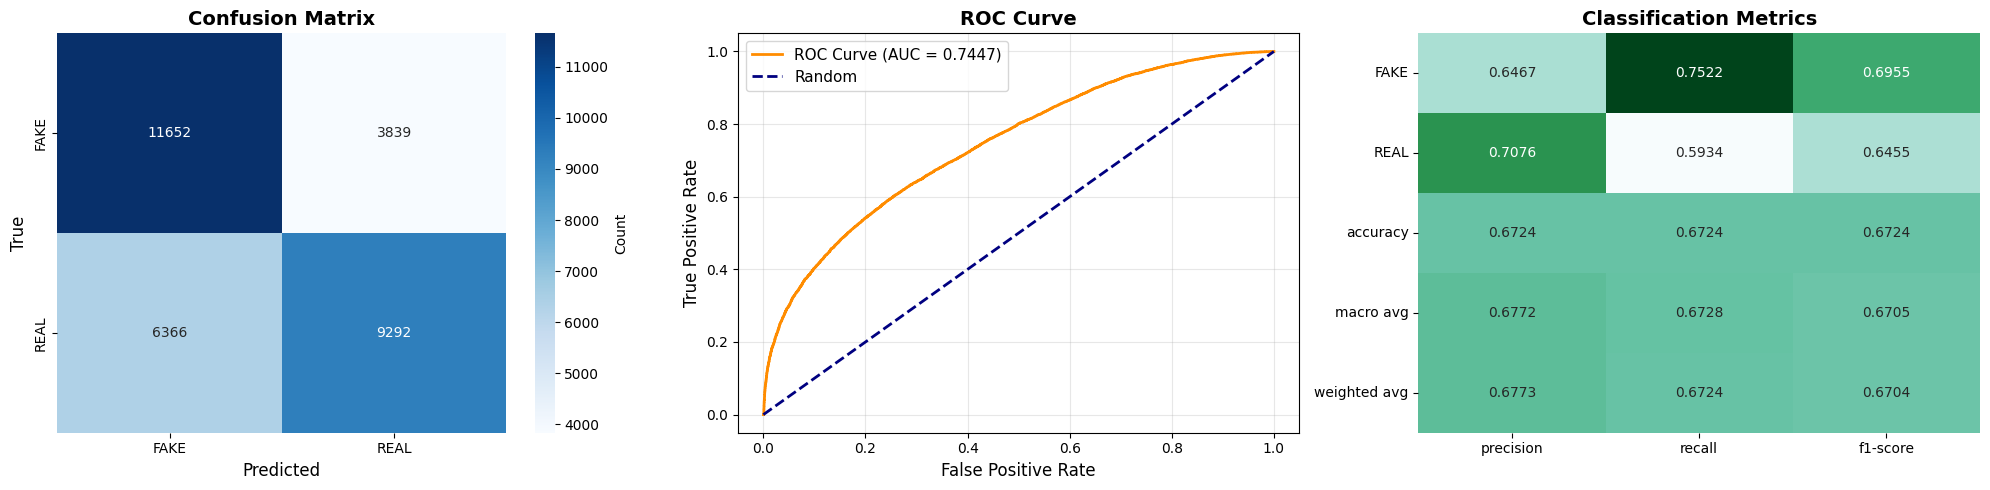


📋 CLASSIFICATION REPORT (Text):
              precision    recall  f1-score   support

        FAKE     0.6467    0.7522    0.6955     15491
        REAL     0.7076    0.5934    0.6455     15658

    accuracy                         0.6724     31149
   macro avg     0.6772    0.6728    0.6705     31149
weighted avg     0.6773    0.6724    0.6704     31149

✅ Visualizations complete!


In [24]:
# ============================================================================
# CNN-SRM Visualizations (Confusion Matrix + ROC + Metrics Table)
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with 3 subplots (Matrix, ROC, and Table)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ========== 1. Confusion Matrix ==========
ax1 = axes[0]
y_pred_binary = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_binary)

# שימוש ב-'Blues' למטריצה
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# ========== 2. ROC Curve ==========
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--', label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# ========== 3. Classification Report Table (Visual) ==========
ax3 = axes[2]

# יצירת הדוח כ-Dictionary
clf_report = classification_report(y_true, y_pred_binary,
                                 target_names=['FAKE', 'REAL'],
                                 output_dict=True)

# המרה ל-DataFrame והסרת שורת ה-Accuracy
report_df = pd.DataFrame(clf_report).iloc[:-1, :].T

# --- התיקון כאן: שינוי ל-'BuGn' (Blue-Green) במקום 'Teal' ---
sns.heatmap(report_df, annot=True, cmap='BuGn', fmt='.4f', ax=ax3, cbar=False)

ax3.set_title('Classification Metrics', fontsize=14, fontweight='bold')
ax3.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# הדפסה טקסטואלית לגיבוי
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT (Text):")
print("="*60)
print(classification_report(y_true, y_pred_binary, target_names=['FAKE', 'REAL'], digits=4))

print("✅ Visualizations complete!")

In [25]:
# ============================================================================
# SECTION 4 Complete - CNN-SRM Summary
# ============================================================================

print("="*60)
print("✅ SECTION 4 COMPLETE: CNN-SRM Model")
print("="*60)
print("\n📋 Summary:")
print("   ✓ create_srm_dataset() function created")
print("   ✓ Train/Val/Test datasets prepared")
print("   ✓ Pre-trained CNN-SRM model loaded")
print("   ✓ Evaluation complete")
print("   ✓ Visualizations generated")

print(f"\n📊 Final Test Results:")
print(f"   Accuracy: {test_results[1]:.4f}")
print(f"   AUC: {test_results[2]:.4f}")

print(f"\n💾 Model loaded from:")
print(f"   {loaded_model_path}")

print("\n💡 Note:")
print("   To train a NEW model with improved parameters,")
print("   see the commented code in cell 22")

print("\n🎯 Next: Section 5 - Xception Model")
print("="*60)

✅ SECTION 4 COMPLETE: CNN-SRM Model

📋 Summary:
   ✓ create_srm_dataset() function created
   ✓ Train/Val/Test datasets prepared
   ✓ Pre-trained CNN-SRM model loaded
   ✓ Evaluation complete
   ✓ Visualizations generated

📊 Final Test Results:
   Accuracy: 0.6724
   AUC: 0.7447

💾 Model loaded from:
   /home/sceuser/RealEyes/gdrive/code/models/NA-VGG/128_SRM_CNN_22_7_25_NEW_openforensics.keras

💡 Note:
   To train a NEW model with improved parameters,
   see the commented code in cell 22

🎯 Next: Section 5 - Xception Model
